### Number of elements in a directory

In [26]:
from pathlib import Path

def count_folder_items(folder_path):
    folder = Path(folder_path)        
    num_items = sum(1 for _ in folder.iterdir())
    
    return num_items

target_folder = "./dataset/flux_outputs_TEST/edited" 

total = count_folder_items(target_folder)
print(f"The folder '{target_folder}' contains {total} items.")

The folder './dataset/flux_outputs_TEST/edited' contains 80 items.


### Check the presence of all needed variants

In [27]:
from pathlib import Path

INPUT_DIR = Path("./dataset/flux_inputs_FULL")
OUTPUT_DIR = Path("./dataset/flux_outputs_FULL/edited")
N_VARIANTS = 9

def check_folder_variants(input_dir, output_dir, n_variants):
    if not input_dir.exists() or not output_dir.exists():
        print("Error: Directory not found.")
        return

    valid_extensions = ('.jpg', '.jpeg', '.png')
    input_images = [f for f in input_dir.iterdir() if f.suffix.lower() in valid_extensions]
    
    if not input_images:
        print("No images found.")
        return

    incomplete_images = {}
    total_missing = 0

    for img_path in input_images:
        base_name = img_path.stem
        missing = []
        
        for i in range(1, n_variants + 1):
            expected_file = output_dir / f"{base_name}_var{i}.jpg"
            if not expected_file.exists():
                missing.append(i)
                total_missing += 1
                
        if missing:
            incomplete_images[img_path.name] = missing

    print(f"Input images: {len(input_images)}")
    print(f"Expected output files: {len(input_images) * n_variants}")

    if not incomplete_images:
        print("Status: All expected variants found.")
    else:
        print(f"Status: Missing files detected.")
        print(f"Total missing files: {total_missing}")
        for img_name, missing_vars in incomplete_images.items():
            print(f"{img_name}: missing variants {missing_vars}")

check_folder_variants(INPUT_DIR, OUTPUT_DIR, N_VARIANTS)

Error: Directory not found.


### Plots ROC and PR Curves

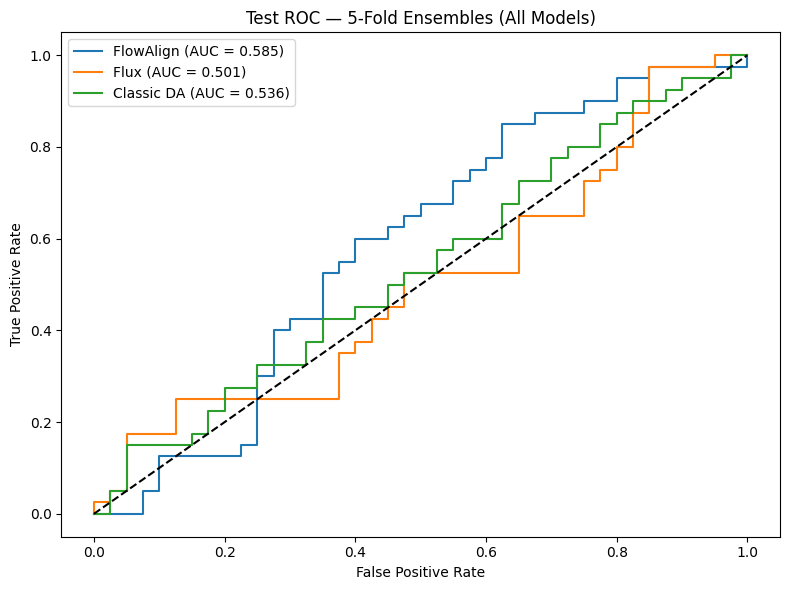

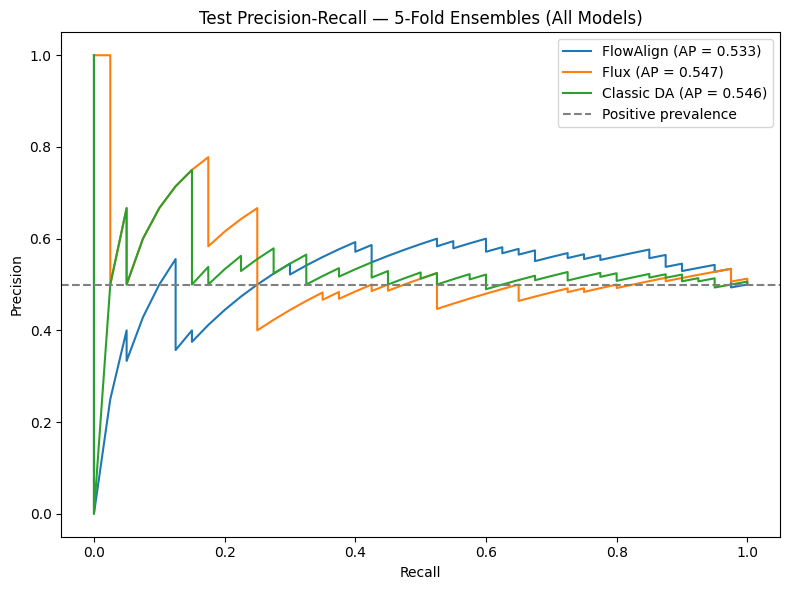

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from pathlib import Path

base_dir = Path("/workspace/seai_project/dataset/k_fold_outputs")
flowalign_path = base_dir / "flowalign_TEST" / "ensemble_classic_balanced_vs_flowalign" / "ensemble_test_predictions.npz"
flux_path = base_dir / "flux_TEST" / "ensemble_classic_balanced_vs_flux" / "ensemble_test_predictions.npz"

data_fa = np.load(flowalign_path)
data_flux = np.load(flux_path)

y_true = data_fa['y_true']

prob_flowalign = data_fa['flowalign_prob'][:, 1]
prob_flux = data_flux['flux_prob'][:, 1]
prob_classic = data_flux['baseline_prob'][:, 1]

fpr_fa, tpr_fa, _ = roc_curve(y_true, prob_flowalign)
fpr_flux, tpr_flux, _ = roc_curve(y_true, prob_flux)
fpr_classic, tpr_classic, _ = roc_curve(y_true, prob_classic)

auc_fa = roc_auc_score(y_true, prob_flowalign)
auc_flux = roc_auc_score(y_true, prob_flux)
auc_classic = roc_auc_score(y_true, prob_classic)

plt.figure(figsize=(8, 6))
plt.plot(fpr_fa, tpr_fa, label=f"FlowAlign (AUC = {auc_fa:.3f})")
plt.plot(fpr_flux, tpr_flux, label=f"Flux (AUC = {auc_flux:.3f})")
plt.plot(fpr_classic, tpr_classic, label=f"Classic DA (AUC = {auc_classic:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC — 5-Fold Ensembles (All Models)")
plt.legend()
plt.tight_layout()
plt.show()

p_fa, r_fa, _ = precision_recall_curve(y_true, prob_flowalign)
p_flux, r_flux, _ = precision_recall_curve(y_true, prob_flux)
p_classic, r_classic, _ = precision_recall_curve(y_true, prob_classic)

ap_fa = average_precision_score(y_true, prob_flowalign)
ap_flux = average_precision_score(y_true, prob_flux)
ap_classic = average_precision_score(y_true, prob_classic)

plt.figure(figsize=(8, 6))
plt.plot(r_fa, p_fa, label=f"FlowAlign (AP = {ap_fa:.3f})")
plt.plot(r_flux, p_flux, label=f"Flux (AP = {ap_flux:.3f})")
plt.plot(r_classic, p_classic, label=f"Classic DA (AP = {ap_classic:.3f})")
plt.axhline(np.mean(y_true == 1), linestyle="--", color="gray", label="Positive prevalence")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall — 5-Fold Ensembles (All Models)")
plt.legend()
plt.tight_layout()
plt.show()

### Statistical Tests

In [29]:
import pandas as pd
from scipy.stats import binomtest, norm

pred_classic = (prob_classic >= 0.5).astype(int)
pred_flux = (prob_flux >= 0.5).astype(int)
pred_fa = (prob_flowalign >= 0.5).astype(int)

def delong_components(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    pos_scores = y_score[y_true == 1]  
    neg_scores = y_score[y_true == 0]  

    if len(pos_scores) < 2 or len(neg_scores) < 2:
        raise ValueError("The DeLong test requires at least two samples per class.")

    pairwise = (pos_scores[:, None] > neg_scores[None, :]).astype(float)
    pairwise += 0.5 * (pos_scores[:, None] == neg_scores[None, :])

    v10 = pairwise.mean(axis=1)
    v01 = pairwise.mean(axis=0)
    auc = v10.mean()
    return auc, v10, v01

def paired_delong_test(y_true, score_1, score_2):
    y_true = np.asarray(y_true)
    auc_1, v10_1, v01_1 = delong_components(y_true, score_1)
    auc_2, v10_2, v01_2 = delong_components(y_true, score_2)

    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    cov_pos = np.cov(np.vstack([v10_1, v10_2]), ddof=1)
    cov_neg = np.cov(np.vstack([v01_1, v01_2]), ddof=1)
    auc_cov = cov_pos / n_pos + cov_neg / n_neg

    auc_diff = auc_2 - auc_1
    var_diff = auc_cov[0, 0] + auc_cov[1, 1] - 2 * auc_cov[0, 1]
    var_diff = max(var_diff, 0.0) 

    if var_diff == 0:
        z = 0.0 if auc_diff == 0 else np.inf
        delong_p_value = 1.0 if auc_diff == 0 else 0.0
    else:
        z = auc_diff / np.sqrt(var_diff)
        delong_p_value = 2 * norm.sf(abs(z))

    return auc_1, auc_2, auc_diff, z, delong_p_value

def run_statistical_tests(model1_name, model2_name, prob1, prob2, pred1, pred2, y_true):
    print(f"\n{'='*15} {model1_name} vs {model2_name} {'='*15}")

    m1_correct = (pred1 == y_true)
    m2_correct = (pred2 == y_true)

    m1_only = np.sum(m1_correct & ~m2_correct)
    m2_only = np.sum(~m1_correct & m2_correct)
    discordant = m1_only + m2_only

    mcnemar_p = binomtest(m2_only, n=discordant, p=0.5, alternative="two-sided").pvalue if discordant > 0 else 1.0

    print("\n--- McNemar Test (Accuracy) ---")
    print(f"{model1_name} correct / {model2_name} incorrect: {m1_only}")
    print(f"{model1_name} incorrect / {model2_name} correct: {m2_only}")
    print(f"p-value: {mcnemar_p:.3e}")
    print("Result:", "STATISTICALLY SIGNIFICANT difference (p < 0.05)" if mcnemar_p < 0.05 else "NON-significant difference (p >= 0.05)")

    auc_1, auc_2, auc_diff, z_stat, delong_p = paired_delong_test(y_true, prob1, prob2)

    print("\n--- DeLong Test (ROC-AUC) ---")
    print(f"{model1_name} ROC-AUC: {auc_1:.4f}")
    print(f"{model2_name} ROC-AUC: {auc_2:.4f}")
    print(f"AUC Difference ({model2_name} - {model1_name}): {auc_diff:+.4f}")
    print(f"z-statistic: {z_stat:.4f}")
    print(f"p-value: {delong_p:.3e}")
    print("Result:", "STATISTICALLY SIGNIFICANT AUC difference (p < 0.05)" if delong_p < 0.05 else "NON-significant AUC difference (p >= 0.05)\n")
    
    return {
        "comparison": f"{model1_name} vs {model2_name}",
        "mcnemar_discordant": int(discordant),
        "mcnemar_p_value": mcnemar_p,
        "auc_1": auc_1,
        "auc_2": auc_2,
        "auc_diff": auc_diff,
        "delong_z": z_stat,
        "delong_p_value": delong_p
    }

results_stats = []

res_flux = run_statistical_tests(
    "Classic DA", "FLUX",
    prob_classic, prob_flux,
    pred_classic, pred_flux,
    y_true
)
results_stats.append(res_flux)

res_fa = run_statistical_tests(
    "Classic DA", "FlowAlign",
    prob_classic, prob_flowalign,
    pred_classic, pred_fa,
    y_true
)
results_stats.append(res_fa)

df_stats = pd.DataFrame(results_stats)
print("=== STATISTICAL TESTS SUMMARY ===")
display(df_stats)


=============== Classic DA vs FLUX ===============

--- McNemar Test (Accuracy) ---
Classic DA correct / FLUX incorrect: 8
Classic DA incorrect / FLUX correct: 7
p-value: 1.000e+00
Result: NON-significant difference (p >= 0.05)

--- DeLong Test (ROC-AUC) ---
Classic DA ROC-AUC: 0.5356
FLUX ROC-AUC: 0.5006
AUC Difference (FLUX - Classic DA): -0.0350
z-statistic: -0.5931
p-value: 5.531e-01
Result: NON-significant AUC difference (p >= 0.05)


=============== Classic DA vs FlowAlign ===============

--- McNemar Test (Accuracy) ---
Classic DA correct / FlowAlign incorrect: 8
Classic DA incorrect / FlowAlign correct: 5
p-value: 5.811e-01
Result: NON-significant difference (p >= 0.05)

--- DeLong Test (ROC-AUC) ---
Classic DA ROC-AUC: 0.5356
FlowAlign ROC-AUC: 0.5850
AUC Difference (FlowAlign - Classic DA): +0.0494
z-statistic: 0.5859
p-value: 5.579e-01
Result: NON-significant AUC difference (p >= 0.05)

=== STATISTICAL TESTS SUMMARY ===


,comparison,mcnemar_discordant,mcnemar_p_value,auc_1,auc_2,auc_diff,delong_z,delong_p_value
0,Classic DA vs FLUX,15,1.000000,0.535625,0.500625,-0.035000,-0.593131,0.553094
1,Classic DA vs FlowAlign,13,0.581055,0.535625,0.585000,0.049375,0.585902,0.557942


In [30]:
import numpy as np
from scipy.stats import binomtest
from pathlib import Path

flowalign_npz_path = Path("dataset/k_fold_outputs/flowalign_TEST/ensemble_classic_balanced_vs_flowalign/ensemble_test_predictions.npz")
flux_npz_path = Path("dataset/k_fold_outputs/flux_TEST/ensemble_classic_balanced_vs_flux/ensemble_test_predictions.npz")

data_flowalign = np.load(flowalign_npz_path)
data_flux = np.load(flux_npz_path)

y_true = data_flux["y_true"] 

y_pred_base = data_flux["baseline_pred"] 

y_pred_flowalign = data_flowalign["flowalign_pred"]
y_pred_flux = data_flux["flux_pred"]

cat_mask = (y_true == 1)

base_cat_pred = y_pred_base[cat_mask]
flowalign_cat_pred = y_pred_flowalign[cat_mask]
flux_cat_pred = y_pred_flux[cat_mask]
n_cats = cat_mask.sum()

def calculate_cat_recall_stats(model_name, y_pred_aug):
    base_cat_correct = (base_cat_pred == 1)
    aug_cat_correct = (y_pred_aug == 1)

    base_cat_recall = base_cat_correct.mean()
    aug_cat_recall = aug_cat_correct.mean()
    recall_diff = aug_cat_recall - base_cat_recall

    base_only_cat = np.sum(base_cat_correct & ~aug_cat_correct)
    aug_only_cat = np.sum(~base_cat_correct & aug_cat_correct)
    discordant_cats = base_only_cat + aug_only_cat

    if discordant_cats > 0:
        p_value = binomtest(aug_only_cat, n=discordant_cats, p=0.5, alternative="two-sided").pvalue
    else:
        p_value = 1.0

    print(f"\n===== CAT RECALL TEST: BASELINE vs {model_name} =====")
    print(f"Real cats in test set: {n_cats}")
    print(f"Baseline cat recall:  {base_cat_recall:.4f}")
    print(f"{model_name} cat recall:     {aug_cat_recall:.4f}")
    print(f"Recall difference ({model_name} - Baseline): {recall_diff:+.4f}")
    print(f"Baseline correct / {model_name} wrong: {base_only_cat}")
    print(f"Baseline wrong / {model_name} correct: {aug_only_cat}")
    
    print(f"Exact McNemar/Binomial p-value: {p_value:.2e}") 
    
    significance = "significant" if p_value < 0.05 else "NO significant"
    print(f"Result: {significance} cat-recall difference (p < 0.05).")

calculate_cat_recall_stats("FlowAlign", flowalign_cat_pred)
calculate_cat_recall_stats("FLUX", flux_cat_pred)


===== CAT RECALL TEST: BASELINE vs FlowAlign =====
Real cats in test set: 40
Baseline cat recall:  0.2250
FlowAlign cat recall:     0.0250
Recall difference (FlowAlign - Baseline): -0.2000
Baseline correct / FlowAlign wrong: 8
Baseline wrong / FlowAlign correct: 0
Exact McNemar/Binomial p-value: 7.81e-03
Result: significant cat-recall difference (p < 0.05).

===== CAT RECALL TEST: BASELINE vs FLUX =====
Real cats in test set: 40
Baseline cat recall:  0.2250
FLUX cat recall:     0.0250
Recall difference (FLUX - Baseline): -0.2000
Baseline correct / FLUX wrong: 8
Baseline wrong / FLUX correct: 0
Exact McNemar/Binomial p-value: 7.81e-03
Result: significant cat-recall difference (p < 0.05).
